In [ ]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
import time
start_time = time.time()


gas_mix_incomplete = ct.Solution('gri30.yaml')

[np.float64(101325.0), np.float64(147856.76376003193), np.float64(215757.43981830636), np.float64(314840.3336657747), np.float64(459425.3425803117), np.float64(670408.5304048249), np.float64(978282.1189516543), np.float64(1427541.3585245316), np.float64(2083115.1779426273), np.float64(3039750.0)]
### EQUIVALENCE RATIO: 0.8 ###
## PRESSURE (Pa): 101325.0 ##
# LAMINAR BURNING SPEED (cm/s): 27.432608980891732 cm/s ###
Run time 16.842950582504272 seconds ---
## PRESSURE (Pa): 147856.76376003193 ##
# LAMINAR BURNING SPEED (cm/s): 23.45886060603276 cm/s ###
Run time 37.364333391189575 seconds ---
## PRESSURE (Pa): 215757.43981830636 ##
# LAMINAR BURNING SPEED (cm/s): 19.764404794564754 cm/s ###
Run time 68.80859303474426 seconds ---
## PRESSURE (Pa): 314840.3336657747 ##
# LAMINAR BURNING SPEED (cm/s): 16.462045352865022 cm/s ###
Run time 100.99251890182495 seconds ---
## PRESSURE (Pa): 459425.3425803117 ##
# LAMINAR BURNING SPEED (cm/s): 13.571916758923496 cm/s ###
Run time 138.702717304229

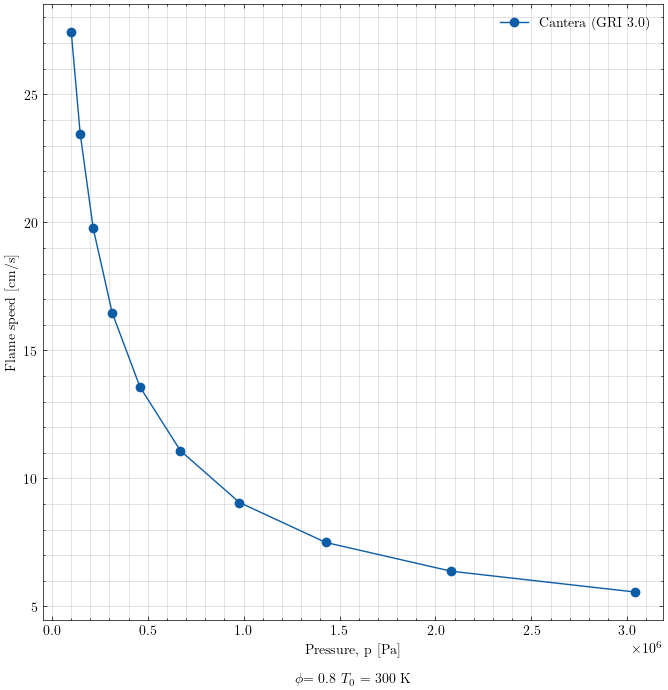

### EQUIVALENCE RATIO: 1.4 ###
## PRESSURE (Pa): 101325.0 ##
# LAMINAR BURNING SPEED (cm/s): 14.087545851200952 cm/s ###
Run time 416.5295512676239 seconds ---
## PRESSURE (Pa): 147856.76376003193 ##
# LAMINAR BURNING SPEED (cm/s): 11.671326693022081 cm/s ###
Run time 431.135372877121 seconds ---
## PRESSURE (Pa): 215757.43981830636 ##
# LAMINAR BURNING SPEED (cm/s): 9.932723489080816 cm/s ###
Run time 445.4068830013275 seconds ---
## PRESSURE (Pa): 314840.3336657747 ##
# LAMINAR BURNING SPEED (cm/s): 8.608258202974074 cm/s ###
Run time 458.17425322532654 seconds ---
## PRESSURE (Pa): 459425.3425803117 ##
# LAMINAR BURNING SPEED (cm/s): 7.64554943804786 cm/s ###
Run time 471.49911665916443 seconds ---
## PRESSURE (Pa): 670408.5304048249 ##
# LAMINAR BURNING SPEED (cm/s): 6.938613175234335 cm/s ###
Run time 485.6909246444702 seconds ---
## PRESSURE (Pa): 978282.1189516543 ##
# LAMINAR BURNING SPEED (cm/s): 6.454788637486749 cm/s ###
Run time 502.83451795578003 seconds ---
## PRESSURE (P

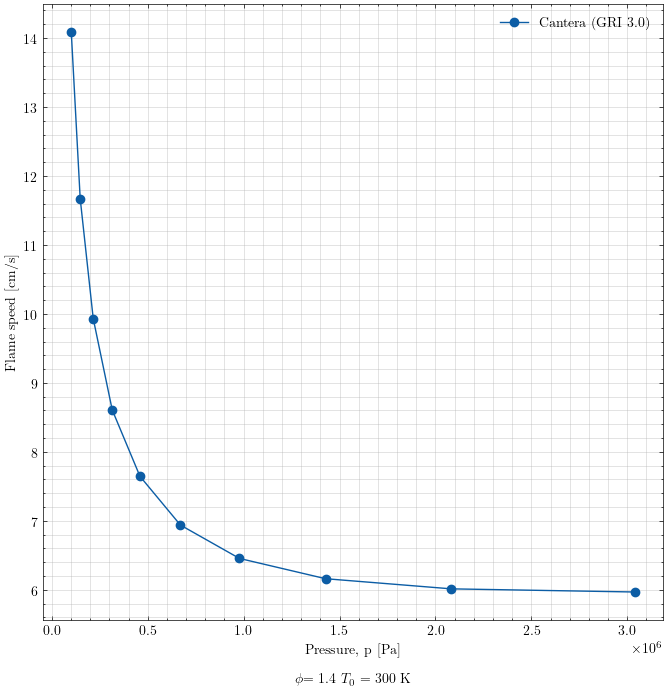

Complete run time --- 553.3181433677673 seconds ---


In [ ]:
T_0 = 300 # K


phi_list = [0.8, 1.4]
p_list = [np.float64(i*ct.one_atm) for i in np.geomspace(1,30,10)]
print(p_list)
# Creo una lista con más densidad de puntos al principio
# con presiones en atm y los multiplico para pasarlo a Pa.

for j, phi in enumerate(phi_list):
    print(f"\033[1;36m### EQUIVALENCE RATIO: {phi} ###\033[0m")

    vel_list = []
    # Hay que vaciar vel_list al acabar cada bucle de presión
    # para no juntar velocidades de todas las phi.
    for p in p_list:
        print(f"\033[1;36m## PRESSURE (Pa): {p} ##\033[0m")

        gas_mix_incomplete.set_equivalence_ratio(phi, 'CH4', 'O2: 1.0, N2: 3.76')
        # Establecimiento de phi en el gas debe ir dentro del bucle de presión.
        gas_mix_incomplete.TP = T_0, p

        # Llama
        flame = ct.FreeFlame(gas=gas_mix_incomplete, width=0.03)
        flame.set_refine_criteria(ratio=3, slope=0.06, curve=0.12)

        if j != 0:
            flame.set_initial_guess(data=flame_sol_previa)

        flame.solve(loglevel=0, refine_grid=True, auto=True)
        flame_sol_previa = flame.to_array()

        print(f"\033[1;36m# LAMINAR BURNING SPEED (cm/s): {flame.velocity[0]*100} cm/s ###\033[0m")
        vel_list.append(flame.velocity[0] * 100) # cm/s
        # plt.plot(flame.grid, flame.velocity)
        # plt.show()


        print("Run time %s seconds ---" % (time.time() - start_time))

    # Plot Speed - phi
    plt.figure(figsize=(8,8))
    plt.plot(p_list,
            vel_list,
            label="Cantera (GRI 3.0)",
            marker="o")
    plt.grid(True, which='both', alpha=0.5)
    plt.xlabel("Pressure, p [Pa] \n \n" + r"$\phi$" + f"= {phi}    $T_{{0}}$ = {T_0} K")
    plt.ylabel("Flame speed [cm/s]")
    plt.legend(loc='best', fontsize=10)
    plt.savefig(f"S_vs_p_w_phi_{phi}.svg")
    plt.show()

print("Complete run time --- %s seconds ---" % (time.time() - start_time))